In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [2]:

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"
ALPHA_TO_COMPARE = 0

SAVE_PLOT = False

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110",
    "apertif"
    "d0"
]

File not found: DM_apertifd0_alpha0_scaled.csv


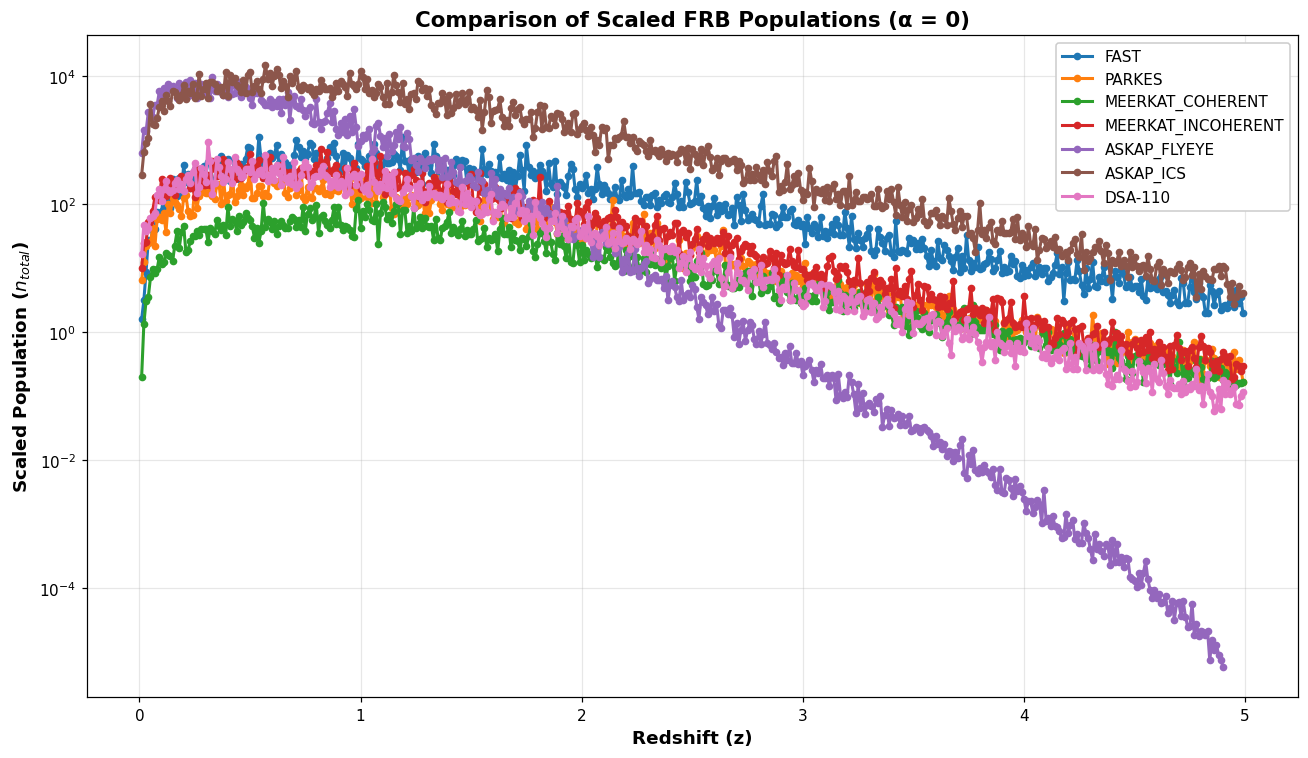


Completed comparison for 7 telescopes.


In [3]:


# ============================================================================
# LOAD AND PLOT
# ============================================================================
plt.figure(figsize=(12, 7), dpi=110)

found_files = 0
for telescope in TELESCOPES:
    # Construct filename based on telescope and alpha
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        
        # Plot Scaled Population vs Redshift
        plt.plot(df['z'], df['n_total_population_scaled'], 
                 marker='o', markersize=4, linewidth=2, label=telescope.upper())
        found_files += 1
    else:
        print(f"File not found: {filename}")

if found_files == 0:
    print(f"No results found for alpha={ALPHA_TO_COMPARE} in {RESULTS_DIR}")
else:
    # Formatting
    plt.title(f'Comparison of Scaled FRB Populations (α = {ALPHA_TO_COMPARE})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Redshift (z)', fontsize=12, fontweight='bold')
    plt.ylabel('Scaled Population ($n_{total}$)', fontsize=12, fontweight='bold')
    
    # Use log scale for Y if the population range is very large
    plt.yscale('log')
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(frameon=True, facecolor='white', framealpha=1)
    
    plt.tight_layout()
    
    if SAVE_PLOT:
        plt.savefig(f"population_comparison_alpha{ALPHA_TO_COMPARE}.png")
    
    plt.show()

print(f"\nCompleted comparison for {found_files} telescopes.")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
RESULTS_DIR = "DM_distribution_new"

# Target redshifts to compare
TARGET_REDSHIFTS = [0.1, 0.3, 0.5, 1.0, 2.0, 4.0]

# List of telescopes to look for
TELESCOPES = [
    "fast", 
    "parkes", 
    "meerkat_coherent", 
    "meerkat_incoherent", 
    "askap_flyeye", 
    "askap_ics",
    "dsa-110",
    "apertif",  # Add this line
]


# ============================================================================
# LOAD DATA FOR ALL TELESCOPES
# ============================================================================
data_dict = {}
for telescope in TELESCOPES:
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        data_dict[telescope] = df
        print(f"✓ Loaded {telescope}")
    else:
        print(f"✗ Not found: {filename}")


✓ Loaded fast
✓ Loaded parkes
✓ Loaded meerkat_coherent
✓ Loaded meerkat_incoherent
✓ Loaded askap_flyeye
✓ Loaded askap_ics
✓ Loaded dsa-110
✓ Loaded apertif


fast                : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    92299.8
parkes              : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    27196.1
meerkat_coherent    : DM range [   10.0,  4990.0] pc/cm³ | Total pop:     9813.5
meerkat_incoherent  : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    49426.7
askap_flyeye        : DM range [   10.0,  4900.0] pc/cm³ | Total pop:   468700.1
askap_ics           : DM range [   10.0,  4990.0] pc/cm³ | Total pop:  1125257.0
dsa-110             : DM range [   10.0,  4990.0] pc/cm³ | Total pop:    40295.3
apertif             : DM range [   10.0,  4990.0] pc/cm³ | Total pop:   107629.6


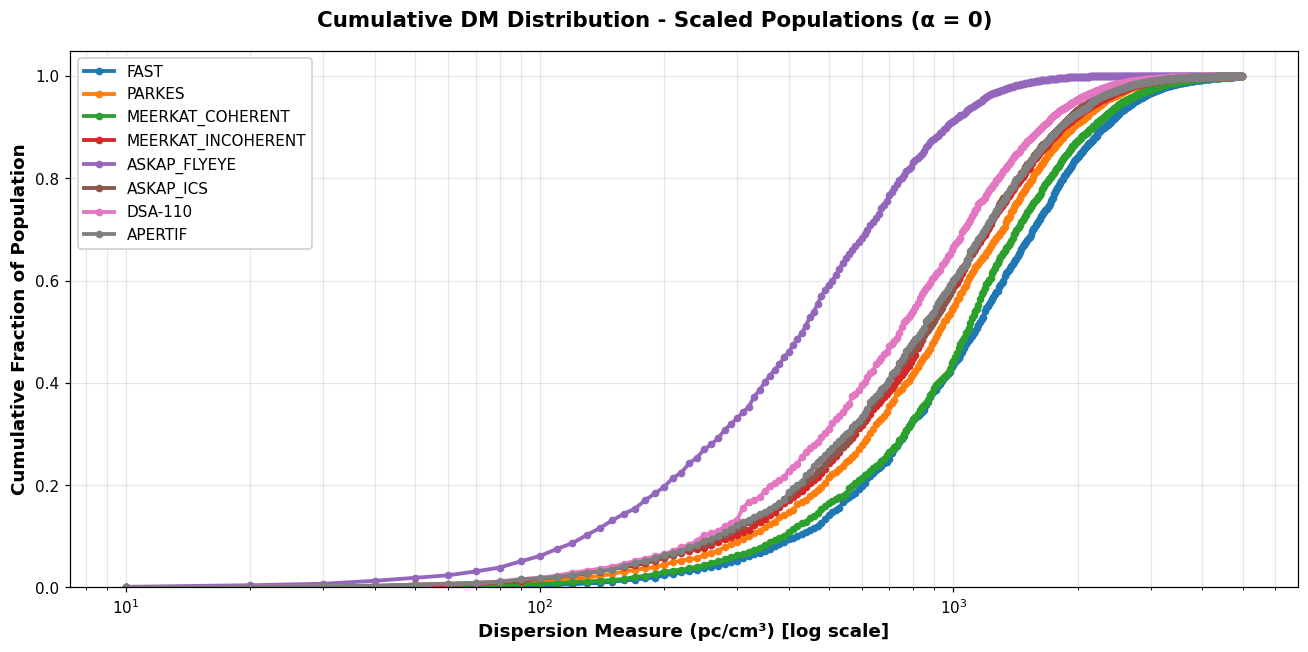


DM STATISTICS SUMMARY
         Telescope  N_Bins DM_min DM_max Total_Population
              FAST     499   10.0 4990.0          92299.8
            PARKES     499   10.0 4990.0          27196.1
  MEERKAT_COHERENT     499   10.0 4990.0           9813.5
MEERKAT_INCOHERENT     499   10.0 4990.0          49426.7
      ASKAP_FLYEYE     490   10.0 4900.0         468700.1
         ASKAP_ICS     499   10.0 4990.0        1125257.0
           DSA-110     499   10.0 4990.0          40295.3
           APERTIF     499   10.0 4990.0         107629.6


In [5]:
# ============================================================================
# CUMULATIVE DM DISTRIBUTION FROM SCALED POPULATIONS
# ============================================================================

# ============================================================================
# LOAD DATA FOR ALL TELESCOPES (if not already loaded)
# ============================================================================
if 'data_dict' not in locals():
    data_dict = {}
    for telescope in TELESCOPES:
        filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
        filepath = os.path.join(RESULTS_DIR, filename)
        
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            data_dict[telescope] = df
            print(f"✓ Loaded {telescope}")
        else:
            print(f"✗ Not found: {filename}")

# ============================================================================
# CONVERT REDSHIFTS TO DM AND CREATE CUMULATIVE DISTRIBUTIONS
# ============================================================================
cumulative_data = {}

for telescope, df in data_dict.items():
    # Convert redshift to DM: DM = z * 1000 pc/cm³
    dm_values = df['z'].values * 1000
    dm_values = np.sort(dm_values)
    
    # Get corresponding scaled populations
    pop_values = df['n_total_population_scaled'].values
    
    # Calculate cumulative distribution (normalized by total population)
    cumulative_pop = np.cumsum(pop_values[np.argsort(df['z'].values)])
    cumulative_fraction = cumulative_pop / cumulative_pop[-1]
    
    cumulative_data[telescope] = {
        'dm': dm_values,
        'cumulative': cumulative_fraction,
        'n_bins': len(dm_values),
        'dm_min': dm_values.min(),
        'dm_max': dm_values.max(),
        'pop_total': pop_values.sum()
    }
    
    print(f"{telescope:20s}: DM range [{dm_values.min():7.1f}, {dm_values.max():7.1f}] pc/cm³ | "
          f"Total pop: {pop_values.sum():10.1f}")

# ============================================================================
# VISUALIZATION: CUMULATIVE DM DISTRIBUTION (LOG SCALE)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6), dpi=110)

# Add main title
fig.suptitle(f'Cumulative DM Distribution - Scaled Populations (α = {ALPHA_TO_COMPARE})', 
             fontsize=14, fontweight='bold')

# Log scale for DM
for telescope, data in cumulative_data.items():
    ax.semilogx(data['dm'], data['cumulative'], marker='o', markersize=4,
                linewidth=2.5, label=f"{telescope.upper()}")

ax.set_xlabel('Dispersion Measure (pc/cm³) [log scale]', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Fraction of Population', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(frameon=True, facecolor='white', framealpha=1, loc='best')
ax.set_ylim([0, 1.05])

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"DM_cumulative_scaled_population_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("DM STATISTICS SUMMARY")
print("="*100)

stats_data = []
for telescope in TELESCOPES:
    if telescope in cumulative_data:
        data = cumulative_data[telescope]
        stats_data.append({
            'Telescope': telescope.upper(),
            'N_Bins': data['n_bins'],
            'DM_min': f"{data['dm_min']:.1f}",
            'DM_max': f"{data['dm_max']:.1f}",
            'Total_Population': f"{data['pop_total']:.1f}"
        })

df_stats = pd.DataFrame(stats_data)
print(df_stats.to_string(index=False))
print("="*100)

In [6]:

# ============================================================================
# CREATE COMPARISON TABLE AT TARGET REDSHIFTS
# ============================================================================
comparison_data = []

for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    for telescope, df in data_dict.items():
        # Find closest redshift
        idx = (df['z'] - target_z).abs().argmin()
        closest_z = df['z'].iloc[idx]
        pop = df['n_total_population_scaled'].iloc[idx]
        row[telescope] = pop
        row[f'{telescope}_z_actual'] = closest_z
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

# Display the table (extract just population values)
print("\n" + "="*100)
print("SCALED POPULATION COMPARISON AT TARGET REDSHIFTS")
print("="*100)

# Create clean display table
display_dict = {}
for target_z in TARGET_REDSHIFTS:
    display_dict[target_z] = {}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    for telescope in TELESCOPES:
        if telescope in data_dict:
            display_dict[target_z][telescope] = row_data[telescope]

display_df = pd.DataFrame(display_dict).T
print(display_df.to_string())



SCALED POPULATION COMPARISON AT TARGET REDSHIFTS
           fast      parkes  meerkat_coherent  meerkat_incoherent  askap_flyeye     askap_ics     dsa-110     apertif
0.1   77.576365   55.317514         11.592165          248.930283   4788.129267   4123.884947  110.794222  273.277012
0.3  275.233004  147.473218         40.627354          199.949875   5298.499518   7829.334859  217.340263  894.096323
0.5  750.431699  336.017363         56.461959          607.748996   4478.280673  11458.005930  312.967538  841.132538
1.0  495.859813  124.941591         42.691684          168.930096    963.546032  12154.747977  291.756753  623.116355
2.0  180.372017   26.741927         22.828701           71.666068     39.221157   1650.455604   37.050374  150.222729
4.0    7.549314    1.367501          0.684479            3.619126      0.002432     30.519507    0.486994    2.798408


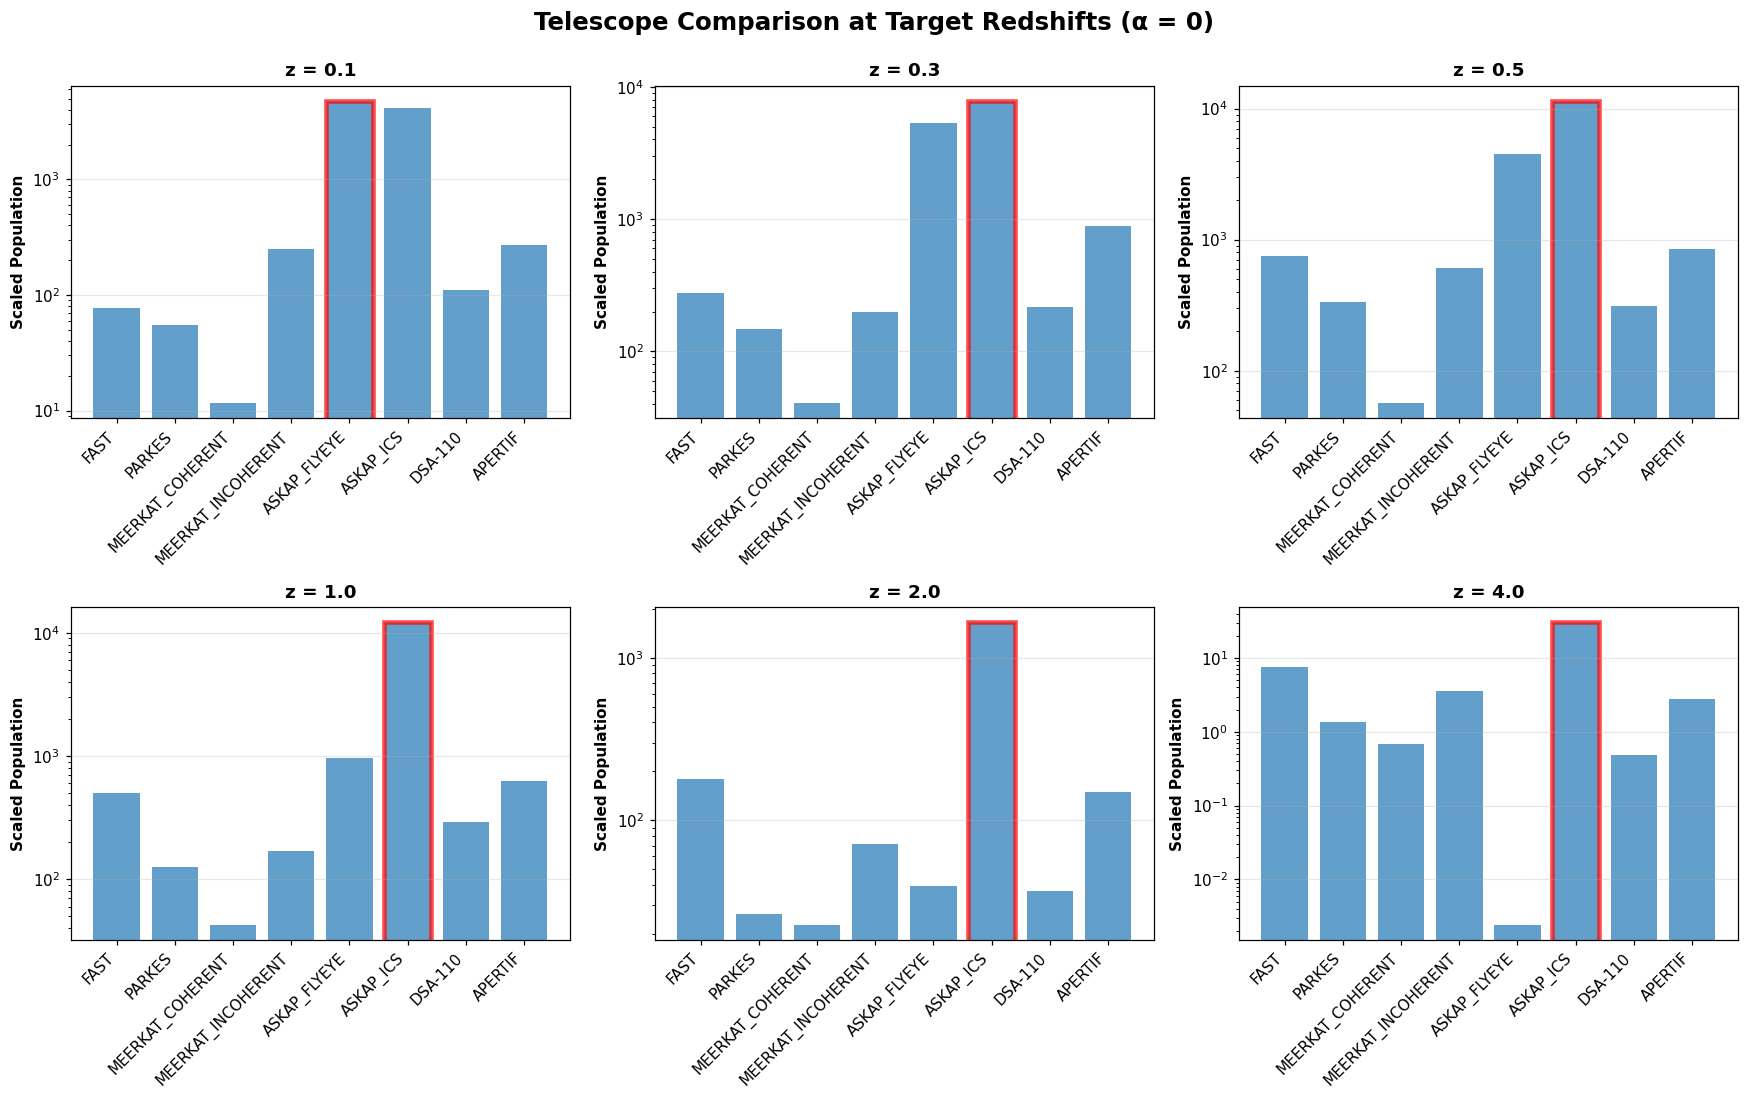


TELESCOPE RANKING AT EACH REDSHIFT (1=Best)
  z                     1                     2                        3                          4                          5                          6               7                       8
0.1 ASKAP_FLYEYE (4788.1)    ASKAP_ICS (4123.9)          APERTIF (273.3) MEERKAT_INCOHERENT (248.9)            DSA-110 (110.8)                FAST (77.6)   PARKES (55.3) MEERKAT_COHERENT (11.6)
0.3    ASKAP_ICS (7829.3) ASKAP_FLYEYE (5298.5)          APERTIF (894.1)               FAST (275.2)            DSA-110 (217.3) MEERKAT_INCOHERENT (199.9)  PARKES (147.5) MEERKAT_COHERENT (40.6)
0.5   ASKAP_ICS (11458.0) ASKAP_FLYEYE (4478.3)          APERTIF (841.1)               FAST (750.4) MEERKAT_INCOHERENT (607.7)             PARKES (336.0) DSA-110 (313.0) MEERKAT_COHERENT (56.5)
1.0   ASKAP_ICS (12154.7)  ASKAP_FLYEYE (963.5)          APERTIF (623.1)               FAST (495.9)            DSA-110 (291.8) MEERKAT_INCOHERENT (168.9)  PARKES (124.9) MEERKAT_C

In [7]:

# ============================================================================
# BAR CHART COMPARISON AT EACH REDSHIFT (SINGLE COLOR FOR ALL BARS)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=110)
axes = axes.flatten()

# Add main title with alpha value at the top
fig.suptitle(f'Telescope Comparison at Target Redshifts (α = {ALPHA_TO_COMPARE})', 
             fontsize=16, fontweight='bold', y=0.995)

# Single color for all bars
bar_color = 'tab:blue'  # Nice blue color

for idx, target_z in enumerate(TARGET_REDSHIFTS):
    ax = axes[idx]
    
    # Get populations for this redshift
    populations = []
    labels = []
    for telescope in TELESCOPES:
        if telescope in data_dict:
            row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
            populations.append(row_data[telescope])
            labels.append(telescope.upper())
    
    # Bar chart with same color for all bars
    bars = ax.bar(range(len(labels)), populations, color=bar_color, alpha = 0.7)
    
    # Find and highlight the best telescope
    best_idx = np.argmax(populations)
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Scaled Population', fontweight='bold')
    ax.set_title(f'z = {target_z}', fontweight='bold', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
# plt.savefig(f"population_comparison_specific_z_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# RANKING TABLE
# ============================================================================
print("\n" + "="*100)
print("TELESCOPE RANKING AT EACH REDSHIFT (1=Best)")
print("="*100)

ranking_data = []
for target_z in TARGET_REDSHIFTS:
    row = {'z': target_z}
    row_data = df_comparison[df_comparison['z'] == target_z].iloc[0]
    
    # Sort telescopes by population
    pop_dict = {tel: row_data[tel] for tel in TELESCOPES if tel in data_dict}
    sorted_tel = sorted(pop_dict.items(), key=lambda x: x[1], reverse=True)
    
    for rank, (tel, pop) in enumerate(sorted_tel, 1):
        row[f'{rank}'] = f"{tel.upper()} ({pop:.1f})"
    
    ranking_data.append(row)

df_ranking = pd.DataFrame(ranking_data)
print(df_ranking.to_string(index=False))

fast                : Total population =     92,299.8
parkes              : Total population =     27,196.1
meerkat_coherent    : Total population =      9,813.5
meerkat_incoherent  : Total population =     49,426.7
askap_flyeye        : Total population =    468,700.1
askap_ics           : Total population =  1,125,257.0
dsa-110             : Total population =     40,295.3
apertif             : Total population =    107,629.6


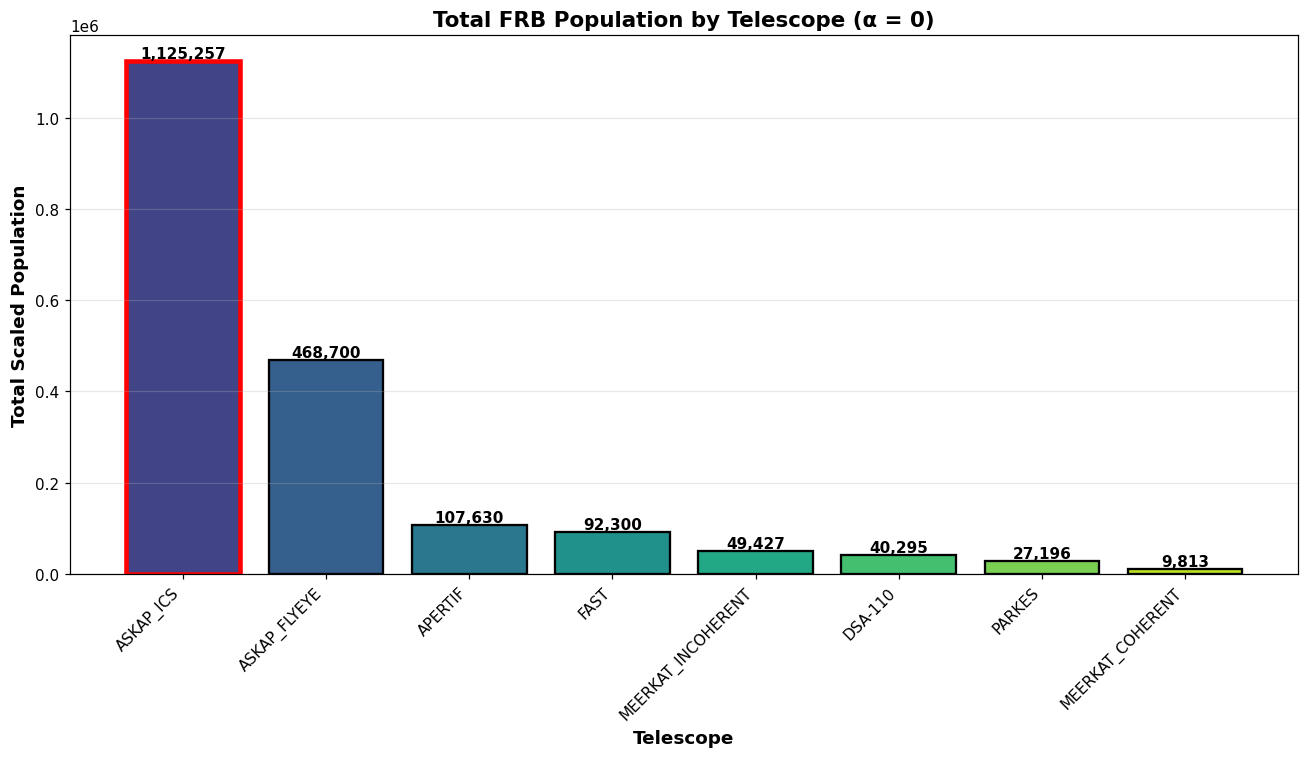


TELESCOPE RANKING BY TOTAL SCALED POPULATION
 Rank          Telescope Total_Population Percentage
    1          ASKAP_ICS      1,125,257.0      58.6%
    2       ASKAP_FLYEYE        468,700.1      24.4%
    3            APERTIF        107,629.6       5.6%
    4               FAST         92,299.8       4.8%
    5 MEERKAT_INCOHERENT         49,426.7       2.6%
    6            DSA-110         40,295.3       2.1%
    7             PARKES         27,196.1       1.4%
    8   MEERKAT_COHERENT          9,813.5       0.5%

Best Telescope: ASKAP_ICS with 1,125,257.0 FRBs
Worst Telescope: MEERKAT_COHERENT with 9,813.5 FRBs
Ratio (Best/Worst): 114.66x


In [8]:
# ============================================================================
# PLOT TOTAL SCALED POPULATION ACROSS ALL TELESCOPES
# ============================================================================

# Load all telescope data
total_populations = {}

for telescope in TELESCOPES:
    filename = f"DM_{telescope}_alpha{ALPHA_TO_COMPARE}_scaled.csv"
    filepath = os.path.join(RESULTS_DIR, filename)
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        total_pop = df['n_total_population_scaled'].sum()
        total_populations[telescope] = total_pop
        print(f"{telescope:20s}: Total population = {total_pop:12,.1f}")
    else:
        print(f"✗ Not found: {filename}")

# Sort by total population (largest to smallest)
sorted_telescopes = sorted(total_populations.items(), key=lambda x: x[1], reverse=True)
tel_names = [t[0].upper() for t in sorted_telescopes]
tel_pops = [t[1] for t in sorted_telescopes]

# ============================================================================
# BAR CHART
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=110)

# Create bars with color gradient
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(tel_names)))
bars = ax.bar(tel_names, tel_pops, color=colors, edgecolor='black', linewidth=1.5)

# Highlight the best (highest population)
bars[0].set_edgecolor('red')
bars[0].set_linewidth(3)

# Add value labels on top of bars
for bar, val in zip(bars, tel_pops):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Telescope', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Scaled Population', fontsize=12, fontweight='bold')
ax.set_title(f'Total FRB Population by Telescope (α = {ALPHA_TO_COMPARE})', 
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f"total_population_by_telescope_alpha{ALPHA_TO_COMPARE}.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# RANKING TABLE
# ============================================================================
print("\n" + "="*80)
print("TELESCOPE RANKING BY TOTAL SCALED POPULATION")
print("="*80)

ranking_df = pd.DataFrame({
    'Rank': range(1, len(sorted_telescopes) + 1),
    'Telescope': tel_names,
    'Total_Population': [f"{pop:,.1f}" for pop in tel_pops],
    'Percentage': [f"{(pop/sum(tel_pops))*100:.1f}%" for pop in tel_pops]
})

print(ranking_df.to_string(index=False))
print("="*80)

print(f"\nBest Telescope: {tel_names[0]} with {tel_pops[0]:,.1f} FRBs")
print(f"Worst Telescope: {tel_names[-1]} with {tel_pops[-1]:,.1f} FRBs")
print(f"Ratio (Best/Worst): {tel_pops[0]/tel_pops[-1]:.2f}x")